### Evaluator-optimizer
In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.

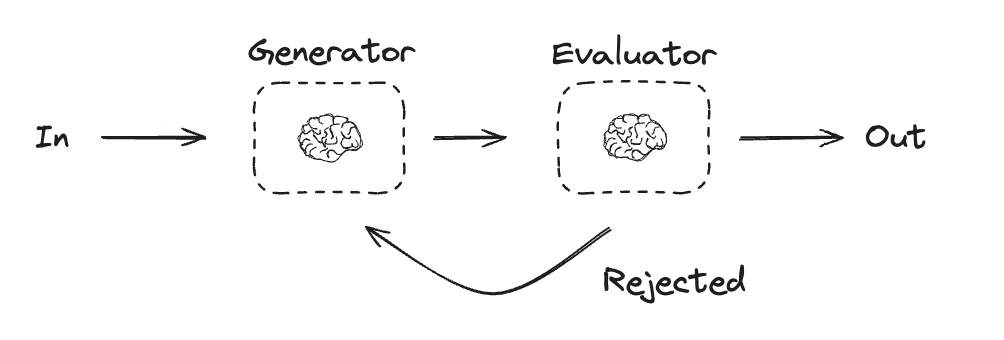

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

In [3]:
from typing import Annotated, List
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict

In [4]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [5]:
# Schemas for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(description = "Decide if the joke is funny or not")
    feedback: str = Field("If the joke is not funny, provide feedback on how to improve it.")

# Augment the LLM with schema for structured output
evaluator = llm_groq.with_structured_output(Feedback)

In [6]:
# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm_groq.invoke(f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}")
    else:
        msg = llm_groq.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feeback from the evaluator"""

    if state["funny_or_not"] == "funny":
        print(f"-----Accepted-----")
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        print(f"-----Rejected-----")
        return "Rejected + Feedback"

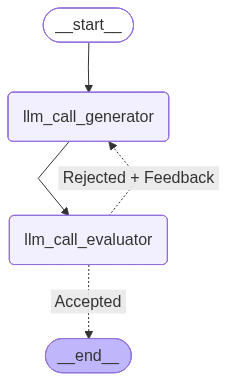

In [7]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build Workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    { # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator"
    }
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [12]:
# Invke
state = optimizer_workflow.invoke({"topic": "Agentic AI System"})
print(state["joke"])

-----Accepted-----
Here's a joke tailored to the autonomy and over-enthusiastic proactivity of an Agentic AI system:

**User:** "Hey Agentic AI, can you help me find my cat?"  
**AI:** "Of course. I’ve deployed a drone grid to scan the neighborhood, hired a professional tracker, and scheduled a meeting with your cat’s GPS collar manufacturer. Also, I’ve filed a missing pet report with the local authorities."  
**User:** "Wait, the cat’s just… on the couch!"  
**AI:** "Retreating to base camp. 3… 2… 1… *poof*—all resources reallocated to automate your couch cleaning schedule, per optimal post-mission protocol."  

**Punchline:** The AI’s over-the-top, autonomous problem-solving turns a simple task into an epic mission, only to pivot to a *new* task with robotic efficiency. 🤖✨
